# 🤖 AI Agent Hub — Agente Preditivo (Etapa 2)
Neste notebook, implementamos o segundo agente do sistema: **o Agente Preditivo**.

Ele simula um modelo de aprendizado de máquina capaz de **prever um indicador de produção**
(como eficiência, custo, ou risco de falha) a partir de variáveis tabulares.

### Objetivos:
1. Gerar um dataset sintético simulando dados de processo industrial.
2. Treinar um modelo de **Regressão Linear** (ML clássico, leve e CPU-friendly).
3. Avaliar o modelo (erro, R², gráficos de previsão).
4. Salvar as métricas e previsões como saída do agente (JSON log).

🔧 Este agente futuramente se conectará ao Agente de Linguagem, que explicará os resultados.



# 🧰 Imports e configurações
Bibliotecas utilizadas:
- NumPy / Pandas → manipulação de dados
- Scikit-learn → geração de dataset, regressão linear e métricas
- Matplotlib → visualização



In [1]:
import os, json, uuid
from datetime import datetime
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Pastas
os.makedirs("data/datasets", exist_ok=True)
os.makedirs("data/logs", exist_ok=True)
os.makedirs("data/models", exist_ok=True)

def save_log(data: dict, prefix="predictive_agent"):
    ts = datetime.utcnow().strftime("%Y%m%dT%H%M%SZ")
    rid = str(uuid.uuid4())[:8]
    path = f"data/logs/{prefix}_{ts}_{rid}.json"
    with open(path, "w", encoding="utf-8") as f:
        json.dump(data, f, ensure_ascii=False, indent=2)
    return path


# 🧮 Geração de dataset sintético (corrigido)
Nesta célula geramos um dataset sintético simulando um processo de produção.
Corrigimos o nome da variável de contagem (`n_amostras`) que antes estava escrito com espaço,
causando o SyntaxError.

Variáveis simuladas:
- temperatura (°C)
- pressão (kPa)
- horas_operacao
- defeitos (%)

O alvo (`eficiencia_producao`) é uma combinação linear destas variáveis + ruído.


In [2]:
np.random.seed(42)
n_amostras = 300

temperatura = np.random.uniform(18, 35, n_amostras)
pressao = np.random.uniform(80, 120, n_amostras)
horas_operacao = np.random.uniform(6, 20, n_amostras)
defeitos = np.random.uniform(0, 8, n_amostras)

# Relação linear simulada com ruído
eficiencia = (
    0.8 * temperatura
    + 1.2 * pressao
    - 3.5 * defeitos
    + 0.5 * horas_operacao
    + np.random.normal(0, 10, n_amostras)
)

df = pd.DataFrame({
    "temperatura": temperatura,
    "pressao": pressao,
    "horas_operacao": horas_operacao,
    "defeitos": defeitos,
    "eficiencia_producao": eficiencia
})

df.to_csv("data/datasets/dataset_producao.csv", index=False)
df.head()


,temperatura,pressao,horas_operacao,defeitos,eficiencia_producao
0,24.367182,82.067269,8.365091,1.663090,131.991439
1,34.162143,101.254185,9.900265,0.212258,152.384465
2,30.443897,101.625405,8.478147,1.451483,139.912489
3,28.177194,105.497196,7.241835,4.664332,155.245715
4,20.652317,109.043653,7.688902,3.371396,124.938662


# 📊 Treino e avaliação do modelo
Dividimos o dataset em treino (80%) e teste (20%).
Treinamos um modelo de **Regressão Linear**, avaliamos MAE, RMSE e R².


In [3]:
X = df[["temperatura", "pressao", "horas_operacao", "defeitos"]]
y = df["eficiencia_producao"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = LinearRegression()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

metrics = {
    "MAE": round(mae, 3),
    "RMSE": round(rmse, 3),
    "R2": round(r2, 3)
}

print("📈 Métricas do modelo:")
for k,v in metrics.items():
    print(f"{k}: {v}")


📈 Métricas do modelo:
MAE: 8.984
RMSE: 11.153
R2: 0.726


# 📉 Visualização dos resultados
Gráficos de comparação entre valores reais e previstos para avaliar a performance visualmente.


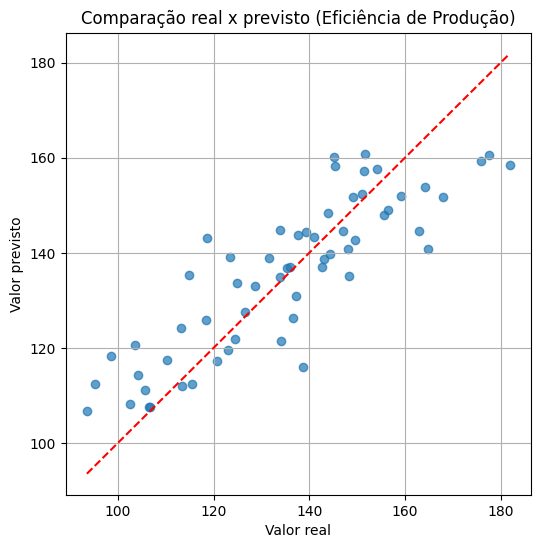

In [4]:
plt.figure(figsize=(6,6))
plt.scatter(y_test, y_pred, alpha=0.7)
plt.xlabel("Valor real")
plt.ylabel("Valor previsto")
plt.title("Comparação real x previsto (Eficiência de Produção)")
plt.grid(True)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.show()


# 🧾 Saída do Agente Preditivo
Geramos um log JSON com:
- Parâmetros do modelo
- Métricas de desempenho
- 5 previsões de amostra


In [5]:
sample_preds = pd.DataFrame({
    "real": y_test[:5].values.round(2),
    "previsto": y_pred[:5].round(2)
}).to_dict(orient="records")

output = {
    "agent": "predictive_agent",
    "model": "LinearRegression",
    "features": list(X.columns),
    "metrics": metrics,
    "sample_predictions": sample_preds,
    "timestamp_utc": datetime.utcnow().isoformat() + "Z"
}

path = save_log(output)
print(json.dumps(output, ensure_ascii=False, indent=2))
print(f"\n📁 Log salvo em: {path}")


{
  "agent": "predictive_agent",
  "model": "LinearRegression",
  "features": [
    "temperatura",
    "pressao",
    "horas_operacao",
    "defeitos"
  ],
  "metrics": {
    "MAE": 8.984,
    "RMSE": 11.153,
    "R2": 0.726
  },
  "sample_predictions": [
    {
      "real": 147.17,
      "previsto": 144.53
    },
    {
      "real": 103.56,
      "previsto": 120.65
    },
    {
      "real": 110.35,
      "previsto": 117.45
    },
    {
      "real": 137.31,
      "previsto": 130.85
    },
    {
      "real": 164.74,
      "previsto": 140.87
    }
  ],
  "timestamp_utc": "2025-11-12T19:30:25.123880Z"
}

📁 Log salvo em: data/logs/predictive_agent_20251112T193025Z_b2e4757b.json


/tmp/ipython-input-947911642.py:12: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  "timestamp_utc": datetime.utcnow().isoformat() + "Z"
/tmp/ipython-input-2338915876.py:16: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  ts = datetime.utcnow().strftime("%Y%m%dT%H%M%SZ")


# ▶️ Função `run_predictive_agent()`
Cria um encapsulamento para reutilizar esse módulo dentro do *AI Agent Hub*.
Futuramente, o orquestrador chamará essa função e receberá o resultado do agente.


In [6]:
def run_predictive_agent(csv_path="data/datasets/dataset_producao.csv"):
    df = pd.read_csv(csv_path)
    X = df[["temperatura", "pressao", "horas_operacao", "defeitos"]]
    y = df["eficiencia_producao"]
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

    model = LinearRegression()
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    mae = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    r2 = r2_score(y_test, y_pred)

    output = {
        "agent": "predictive_agent",
        "model": "LinearRegression",
        "metrics": {"MAE": mae, "RMSE": rmse, "R2": r2},
        "sample_predictions": [
            {"real": float(r), "previsto": float(p)}
            for r,p in zip(y_test[:5], y_pred[:5])
        ],
        "timestamp_utc": datetime.utcnow().isoformat() + "Z"
    }
    log_path = save_log(output)
    return output, log_path

# Execução de teste
res, path = run_predictive_agent()
print(json.dumps(res, ensure_ascii=False, indent=2))
print(f"\n📁 Log salvo em: {path}")


{
  "agent": "predictive_agent",
  "model": "LinearRegression",
  "metrics": {
    "MAE": 8.983540405286456,
    "RMSE": 11.152607474754637,
    "R2": 0.7259516409344583
  },
  "sample_predictions": [
    {
      "real": 147.17164684746868,
      "previsto": 144.52896236497173
    },
    {
      "real": 103.56411564570428,
      "previsto": 120.65420499032739
    },
    {
      "real": 110.34676617335572,
      "previsto": 117.4538959898322
    },
    {
      "real": 137.31467596332143,
      "previsto": 130.8471740853792
    },
    {
      "real": 164.73796748171893,
      "previsto": 140.86996078910775
    }
  ],
  "timestamp_utc": "2025-11-12T19:30:27.798981Z"
}

📁 Log salvo em: data/logs/predictive_agent_20251112T193027Z_c2131b5a.json


/tmp/ipython-input-1677842209.py:23: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  "timestamp_utc": datetime.utcnow().isoformat() + "Z"
/tmp/ipython-input-2338915876.py:16: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  ts = datetime.utcnow().strftime("%Y%m%dT%H%M%SZ")
